## CMAPSS Predictive Maintenance - ML Pipeline
### Notebook 3: RUL Zone Classification

In [0]:
"""CLASSIFICATION
    - Model: XGBoost CLassifier | Tracking: MLflow
    - Input: gold_ml_train, gold_ml_test
"""

import mlflow
import mlflow.xgboost
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


mlflow.set_experiment("/cmapss_rul_classification")

print(f"XGBoost version: {xgb.__version__}")
print("MLflow experiment set: /cmapss_rul_classification")

XGBoost version: 3.2.0
MLflow experiment set: /cmapss_rul_classification


In [0]:
"""Load ML data and convert to pandas"""

KEY_SENSORS = ["sensor_2", "sensor_3", "sensor_4", "sensor_7",
               "sensor_11", "sensor_12", "sensor_15", "sensor_17",
               "sensor_20", "sensor_21"]

ALL_SENSORS = [f"sensor_{i}" for i in range(1, 22)]

roll_mean_5_cols  = [f"{s}_roll_mean_5"  for s in KEY_SENSORS]
roll_mean_10_cols = [f"{s}_roll_mean_10" for s in KEY_SENSORS]
roll_mean_30_cols = [f"{s}_roll_mean_30" for s in KEY_SENSORS]
roll_std_10_cols  = [f"{s}_roll_std_10"  for s in KEY_SENSORS]

FEATURE_COLS = (
    ["dataset_id_encoded",
     "op_setting_1", "op_setting_2", "op_setting_3"] +
    ALL_SENSORS +
    roll_mean_5_cols +
    roll_mean_10_cols +
    roll_mean_30_cols +
    roll_std_10_cols
)

CLASSIFICATION_TARGET = "rul_zone"

train_df = spark.read.format("delta").table("cmapss_project.gold.gold_ml_train").toPandas()
test_df  = spark.read.format("delta").table("cmapss_project.gold.gold_ml_test").toPandas()

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (160359, 70)
Test shape:  (707, 70)


In [0]:
"""Encode zone labels to integers for XGBoost classifier
Zone mapping:
    - 1_Critical = 0
    - 2_Warning = 1
    - 3_Moderate = 2
    - 4_Healthy = 3
"""

le = LabelEncoder()
le.fit(train_df[CLASSIFICATION_TARGET])

train_df["rul_zone_encoded"] = le.transform(train_df[CLASSIFICATION_TARGET])
test_df["rul_zone_encoded"] = le.transform(test_df[CLASSIFICATION_TARGET])

# Store mapping
zone_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
reverse_mapping = {v: k for k, v in zone_mapping.items()}

print("Zone encoding:")
for zone, code in zone_mapping.items():
    print(f"  {zone} = {code}")

Zone encoding:
  1_Critical = 0
  2_Warning = 1
  3_Moderate = 2
  4_Healthy = 3


In [0]:
"""Train/Validation Split
Stratify dataset to ensure all 4 zones in both
"""

X = train_df[FEATURE_COLS]
y = train_df["rul_zone_encoded"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_test = test_df[FEATURE_COLS]
y_test = test_df["rul_zone_encoded"]

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

print("\nClass distribution in training set:")
for code, zone in reverse_mapping.items():
    count = (y_train ==code).sum()
    pct = count / len(y_train) * 100
    print(f"  {zone} = {count} ({pct:.1f}%)")


X_train: (128287, 65) | y_train: (128287,)
X_val:   (32072, 65)   | y_val:   (32072,)
X_test:  (707, 65)  | y_test:  (707,)

Class distribution in training set:
  1_Critical = 14747 (11.5%)
  2_Warning = 14180 (11.1%)
  3_Moderate = 28360 (22.1%)
  4_Healthy = 71000 (55.3%)


In [0]:
"""Run 1: Baseline XGBoost Classifier"""

with mlflow.start_run(run_name="baseline_xgb_classifier"):
    mlflow.log_param("run_type", "baseline")
    mlflow.log_param("n_classes", 4)
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("rul_cap", 125)

    params_base = {
        "n_estimators": 100,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "multi:softmax",
        "num_class": 4, 
        "random_state": 42,
        "n_jobs": -1
    }

    mlflow.log_params(params_base)

    clf_baseline = xgb.XGBClassifier(**params_base)
    clf_baseline.fit(
        X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
    )

    # Evaluate
    val_preds_b = clf_baseline.predict(X_val)
    val_acc_b = accuracy_score(y_val, val_preds_b)
    val_f1_b = f1_score(y_val, val_preds_b, average="weighted")

    test_preds_b = clf_baseline.predict(X_test)
    test_acc_b   = accuracy_score(y_test, test_preds_b)
    test_f1_b    = f1_score(y_test, test_preds_b, average="weighted")

    mlflow.log_metric("val_accuracy", round(val_acc_b, 4))
    mlflow.log_metric("val_f1", round(val_f1_b, 4))
    mlflow.log_metric("test_accuracy", round(test_acc_b, 4))
    mlflow.log_metric("test_f1", round(test_f1_b, 4))

    mlflow.xgboost.log_model(clf_baseline, name="model")

    print("=== Baseline Classifier Results ===")
    print(f"Validation - Accuracy: {val_acc_b:.4f} | F1: {val_f1_b:.4f}")
    print(f"Test - Accuracy: {test_acc_b:.4f} | F1: {test_f1_b:.4f}")

🔗 View Logged Model at: https://dbc-10cea8d5-2939.cloud.databricks.com/ml/experiments/2935484494188021/models/m-3621c0d627314dcbad6aa53f0c85c153?o=7474644282565291
2026/04/24 01:11:00 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


=== Baseline Classifier Results ===
Validation - Accuracy: 0.7689 | F1: 0.7492
Test - Accuracy: 0.6818 | F1: 0.6561


In [0]:
"""Run 2: Tuned XGBoost Classifier"""

with mlflow.start_run(run_name="tuned_xgb_classifier"):

    mlflow.log_param("run_type", "tuned")
    mlflow.log_param("n_classes", 4)
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("rul_cap", 125)

    params_tuned = {
        "n_estimators":     500,
        "max_depth":        8,
        "learning_rate":    0.05,
        "subsample":        0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 3,
        "gamma":            0.1,
        "reg_alpha":        0.1,
        "reg_lambda":       1.0,
        "objective":        "multi:softmax",
        "num_class":        4,
        "random_state":     42,
        "n_jobs":           -1
    }

    mlflow.log_params(params_tuned)
    clf_tuned = xgb.XGBClassifier(**params_tuned)
    clf_tuned.fit(
        X_train, y_train, eval_set=[(X_val, y_val)], verbose=False
    )

    # Evaluate
    val_preds_t = clf_tuned.predict(X_val)
    val_acc_t = accuracy_score(y_val, val_preds_t)
    val_f1_t = f1_score(y_val, val_preds_t, average="weighted")

    test_preds_t = clf_tuned.predict(X_test)
    test_acc_t   = accuracy_score(y_test, test_preds_t)
    test_f1_t    = f1_score(y_test, test_preds_t, average="weighted")

    # Per-class F1
    per_class_f1 = f1_score(y_test, test_preds_t, average=None)

    mlflow.log_metric("val_accuracy", round(val_acc_t, 4))
    mlflow.log_metric("val_f1", round(val_f1_t, 4))
    mlflow.log_metric("test_accuracy", round(test_acc_t, 4))
    mlflow.log_metric("test_f1", round(test_f1_t, 4))

    for i, f1 in enumerate(per_class_f1):
        zone_name = reverse_mapping[i].replace(" ", "_")
        mlflow.log_metric(f"f1_{zone_name}", round(f1, 4))

    mlflow.xgboost.log_model(clf_tuned, name="model")

    print("=== Tuned Classifier Results ===")
    print(f"Validation - Accuracy: {val_acc_t:.4f} | F1: {val_f1_t:.4f}")
    print(f"Test - Accuracy: {test_acc_t:.4f} | F1: {test_f1_t:.4f}")
    print(f"\nPer-class F1 on test set:")
    for i, f1 in enumerate(per_class_f1):
        print(f"  {reverse_mapping[i]}: {f1:.4f}")  

🔗 View Logged Model at: https://dbc-10cea8d5-2939.cloud.databricks.com/ml/experiments/2935484494188021/models/m-6aa19b741a5249979f1e787598cd54a7?o=7474644282565291
2026/04/24 01:12:01 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


=== Tuned Classifier Results ===
Validation - Accuracy: 0.8106 | F1: 0.8018
Test - Accuracy: 0.6959 | F1: 0.6824

Per-class F1 on test set:
  1_Critical: 0.8929
  3_Moderate: 0.4986
  4_Healthy: 0.7690


In [0]:
"""Full classification report
Most important metric : recall on 1_Critical
"""
print("=== Full Classification Report (Tuned Model, Test Set) ===\n")
print(classification_report(
    y_test,
    test_preds_t,
    target_names=[reverse_mapping[i] for i in range(4)]
))

=== Full Classification Report (Tuned Model, Test Set) ===

              precision    recall  f1-score   support

  1_Critical       0.91      0.87      0.89       143
   2_Warning       0.54      0.55      0.55        87
  3_Moderate       0.63      0.41      0.50       220
   4_Healthy       0.68      0.89      0.77       257

    accuracy                           0.70       707
   macro avg       0.69      0.68      0.68       707
weighted avg       0.69      0.70      0.68       707



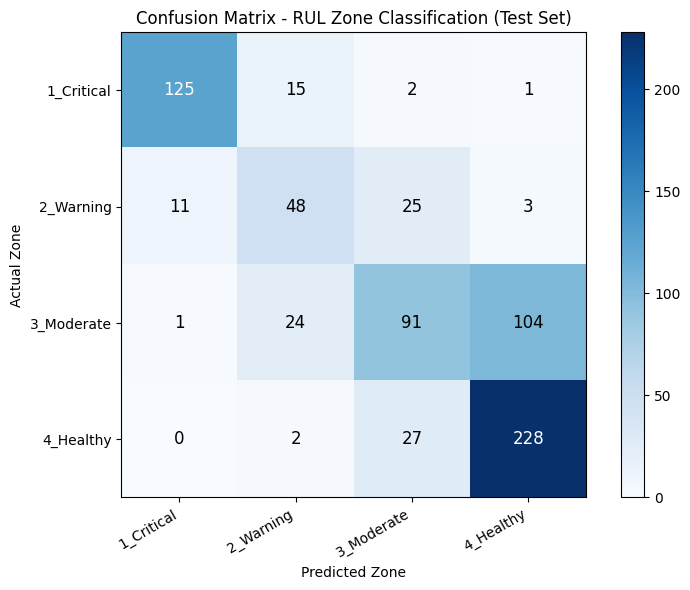

In [0]:
"""Confusion matrix"""

zone_labels = [reverse_mapping[i] for i in range(4)]
cm = confusion_matrix(y_test, test_preds_t)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im)

ax.set(
    xticks=np.arange(4),
    yticks=np.arange(4),
    xticklabels=zone_labels,
    yticklabels=zone_labels,
    xlabel="Predicted Zone",
    ylabel="Actual Zone",
    title="Confusion Matrix - RUL Zone Classification (Test Set)"
)

plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

# Annotate cells with counts
thresh = cm.max() / 2.0
for i in range(4):
    for j in range(4):
        ax.text(j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=12)

plt.tight_layout()
plt.show()

In [0]:
print("\nCritical zone breakdown:")
print(f"  Correctly identified as Critical: {cm[0][0]}")
print(f"  Misclassified as Warning:         {cm[0][1]}")
print(f"  Misclassified as Moderate:        {cm[0][2]}")
print(f"  Misclassified as Healthy:         {cm[0][3]}  ← most dangerous")


Critical zone breakdown:
  Correctly identified as Critical: 125
  Misclassified as Warning:         15
  Misclassified as Moderate:        2
  Misclassified as Healthy:         1  ← most dangerous


In [0]:
"""Per-dataset accuracy"""
test_df_cls = test_df.copy()
test_df_cls["predicted_zone"] = clf_tuned.predict(X_test)
test_df_cls["correct"] = (test_df_cls["predicted_zone"] == test_df_cls["rul_zone_encoded"]).astype(int)

per_dataset_cls = test_df_cls.groupby("dataset_id").agg(
    accuracy = ("correct", "mean"),
    engine_count = ("unit_id", "count")
).round(4)

per_dataset_cls["accuracy_pct"] = (per_dataset_cls["accuracy"] * 100).round(1)

print("Per-dataset classification accuracy:")
print(per_dataset_cls)

Per-dataset classification accuracy:
            accuracy  engine_count  accuracy_pct
dataset_id                                      
FD001         0.6500           100          65.0
FD002         0.7297           259          73.0
FD003         0.7300           100          73.0
FD004         0.6653           248          66.5


In [0]:
best_clf = clf_tuned if test_f1_t > test_f1_b else clf_baseline
best_f1 = max(test_f1_t, test_f1_b)
best_run = "tuned" if test_f1_t > test_f1_b else "baseline"

print(f"Best classifier: {best_run} | Test F1: {best_f1:.4f}")

from mlflow.models import infer_signature

signature = infer_signature(
    X_test,
    best_clf.predict(X_test)
)


with mlflow.start_run(run_name="register_best_classifier"):
    mlflow.xgboost.log_model(
        best_clf,
        name="model",
        input_example=X_test.iloc[:5],
        signature=signature,
        registered_model_name="cmapss_rul_classifier"
    )
    mlflow.log_metric("test_f1", round(best_f1, 4))
    mlflow.log_metric("test_accuracy", round(test_acc_t, 4))
    mlflow.log_param("best_run", best_run)
    mlflow.log_param("n_classes", 4)
    mlflow.log_param("zones", "Critical/Warning/Moderate/Healthy")


Best classifier: tuned | Test F1: 0.6824


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://dbc-10cea8d5-2939.cloud.databricks.com/ml/experiments/2935484494188021/models/m-a194306fdf814fcabbb7d569daccdf9b?o=7474644282565291
Registered model 'cmapss_rul_classifier' already exists. Creating a new vers

Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

🔗 Created version '2' of model 'workspace.default.cmapss_rul_classifier': https://dbc-10cea8d5-2939.cloud.databricks.com/explore/data/models/workspace/default/cmapss_rul_classifier/version/2?o=7474644282565291
